In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
import pickle

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings("ignore")

random.seed(42)
np.random.seed(42)





In [4]:
df=pd.read_csv("data.csv")
print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

In [ ]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               4000 non-null   int64
 1   title                4000 non-null   str  
 2   location             4000 non-null   str  
 3   department           2277 non-null   str  
 4   salary_range         2585 non-null   str  
 5   company_profile      3731 non-null   str  
 6   description          4000 non-null   str  
 7   requirements         3865 non-null   str  
 8   benefits             3013 non-null   str  
 9   telecommuting        4000 non-null   int64
 10  has_company_logo     4000 non-null   int64
 11  has_questions        4000 non-null   int64
 12  employment_type      4000 non-null   str  
 13  required_experience  3857 non-null   str  
 14  required_education   3857 non-null   str  
 15  industry             3837 non-null   str  
 16  function             3854 non-null 

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000
mean,2000.500000,0.17175,0.806750,0.578750,0.120000
std,1154.844867,0.37721,0.394897,0.493821,0.325002
min,1.000000,0.00000,0.000000,0.000000,0.000000
25%,1000.750000,0.00000,1.000000,0.000000,0.000000
50%,2000.500000,0.00000,1.000000,1.000000,0.000000
75%,3000.250000,0.00000,1.000000,1.000000,0.000000
max,4000.000000,1.00000,1.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()




job_id                    0
title                     0
location                  0
department             1723
salary_range           1415
company_profile         269
description               0
requirements            135
benefits                987
telecommuting             0
has_company_logo          0
has_questions             0
employment_type           0
required_experience     143
required_education      143
industry                163
function                146
fraudulent                0
dtype: int64

In [ ]:
df['department']=df['department'].fillna('Unknown', inplace=True)
df['salary_range']=df['salary_range'].fillna('Unknown', inplace=True)
df['company_profile']=df['company_profile'].fillna('Unknown',inplace=True)
df['requirements']=df['requirements'].fillna('Unknown',inplace=True)
df['benefits']=df['benefits'].fillna('Unknown',inplace=True)
df['required_experience']=df['required_experience'].fillna('Unspecified',inplace=True)
df['required_education']=df['required_education'].fillna('Unspecified',inplace=True)
df['industry']=df['industry'].fillna('Unknown',inplace=True)
df['function']=df['function'].fillna(' Unknown',inplace=True)



In [ ]:
df.isnull().sum()

job_id                 0
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

In [ ]:
print(df.duplicated().sum())

0


2
fraudulent
0    3520
1     480
Name: count, dtype: int64
                    job_id  telecommuting  has_company_logo  has_questions  \
job_id            1.000000      -0.025342         -0.000506      -0.009394   
telecommuting    -0.025342       1.000000         -0.280747      -0.137736   
has_company_logo -0.000506      -0.280747          1.000000       0.203085   
has_questions    -0.009394      -0.137736          0.203085       1.000000   
fraudulent        0.004507       0.456009         -0.620060      -0.317539   

                  fraudulent  
job_id              0.004507  
telecommuting       0.456009  
has_company_logo   -0.620060  
has_questions      -0.317539  
fraudulent          1.000000  


<Axes: >

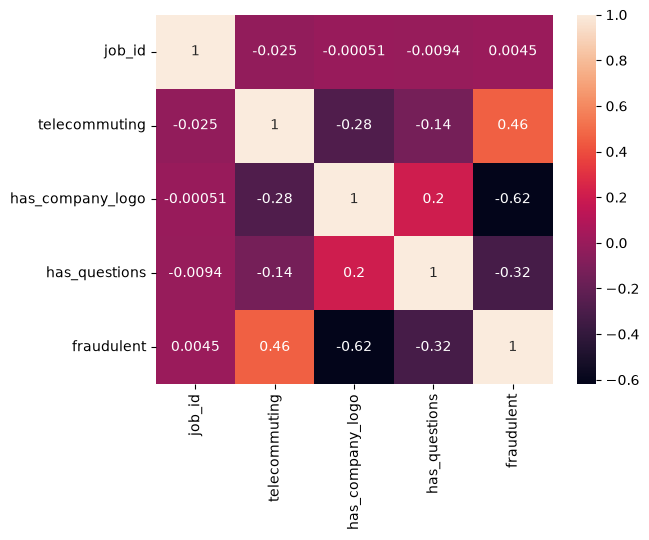

In [ ]:
print(df['fraudulent'].nunique())
print(df['fraudulent'].value_counts())
print(df.corr(numeric_only=True))
sns.heatmap(df.corr(numeric_only=True), annot=True)
            

In [ ]:
text_cols=['title','company_profile','description','requirements','benefits']
df['full_text']=df[text_cols].agg(' '.join, axis=1)

In [ ]:
x=df.drop('fraudulent',axis=1)
y=df['fraudulent']
print(x.shape)
print(y.shape)


(4000, 17)
(4000,)


In [7]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("traning samples:",x_train.shape)
print("testing samples:",x_test.shape)

NameError: name 'x' is not defined

In [6]:
tfidf=TfidfVectorizer(max_features=5000,stop_words='english',
                      ngram_range=(1,2),min_df=2,max_df=0.9)
x_train_tfidf=tfidf.fit_transform(x_train['full_text'])
x_test_tfidf=tfidf.transform(x_test['full_text'])
print(x_train_tfidf.shape,x_test_tfidf.shape)

NameError: name 'x_train' is not defined